# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import re
import random
from tqdm import tqdm_notebook
import torch
from torch import nn
import torch.nn.functional as F

# reproducing same results
SEED = 2019
torch.manual_seed(SEED)

# 2. Load Dataset

In [2]:
# open text file and read in data
with open(r"Dailog-dataset.dialogs_dataset", "rb") as f:
    dialogs = pickle.load(f)

In [3]:
len(dialogs)

64776

In [4]:
random.sample(dialogs, 10)

['Hey, Assistant, what theaters are showing Spider-Man: Into the Spider-Verse tonight?',
 'You can use my info',
 'The price sound right',
 'Yes, that should be just fine! A booth reservation for three at seven PM, then',
 "No, that's all",
 "Yes, let's go with the later reservation because it's worth it to be on the water",
 'We will need the reservation for Tuesday night',
 "Yes, that's correct",
 'Oh, standard is fine',
 'I would like to schedule an appointment with Intelligent Auto Solutions']

## 3.1 Text Cleaning

In [5]:
from collections import Counter

def clean_text(dialogs):
    cleaned_texts = []
    for dialog in dialogs:
        text = re.sub("[^a-zA-Z' ]", "", dialog).lower()
        cleaned_texts.append(text)
    return cleaned_texts

def count_words(texts):
    all_words = " ".join(texts).split()
    word_counts = Counter(all_words)
    return dict(word_counts)

dialogs_clean = clean_text(dialogs)
words_dict = count_words(dialogs_clean)

In [6]:
random.sample(dialogs_clean, 10)

['well do that',
 'do you know how i like it by now',
 "i want to order a pizza from domino's",
 'i want to book a restaurant for dinner',
 'i will be in barrington',
 ' let me know if you have a problem',
 "well let's try somewhere else ",
 'can you tell them to double toast the chocolate croissant',
 ' have a good evening',
 ' is there something sooner']


## 3.2 Finding Word Count

In [7]:
# prepare a dataframe
words_df = pd.DataFrame({'word':list(words_dict.keys()), 'count':list(words_dict.values())})
words_df = words_df.sort_values(by = ['count'])
words_df.reset_index(inplace = True, drop=True)

In [8]:
len(words_df)

11147

In [9]:
words_df.head()

,word,count
0,tornado,1
1,vfw,1
2,evelyn,1
3,stoplights,1
4,vicky,1


In [10]:
words_df.tail()

,word,count
11142,you,11909
11143,a,13380
11144,to,14000
11145,the,15406
11146,i,19654


## 3.3 Find and Replace Rare Words with "Unknown" Token

In [11]:
# threshold value for finding unique set of words
rare_thresh = 4

def get_rare_words_info(words_df, threshold):
    rare_words = words_df[words_df['count'] < threshold]['word'].tolist()
    rare_dist = len(rare_words) / len(words_df)
    rare_cover = words_df[words_df['count'] < threshold]['count'].sum() / words_df['count'].sum()
    return rare_words, rare_dist, rare_cover

rare_words, rare_dist, rare_cover = get_rare_words_info(words_df, rare_thresh)

print(f"Distribution of unique words in the vocabulary: {rare_dist*100:.2f}")
print(f"Coverage of rare words in the corpus: {rare_cover*100:.2f}")

Distribution of unique words in the vocabulary: 69.03
Coverage of rare words in the corpus: 2.27


In [12]:
def replace_rare_words(texts, rare_words):

    dialogs_cleaned = []
    pattern = ""
    for i in rare_words:
        pattern+= "{} |".format(i)

    pattern = pattern[:-1]
    for text in tqdm_notebook(texts, "Replacing rare words"):
        text = re.sub(pattern, " <unk> ", text)
        dialogs_cleaned.append(text)

    return dialogs_cleaned

dialogs_clean_v2 = replace_rare_words(dialogs_clean, rare_words)
dialogs_clean_v2[500:510]

<ipython-input-12-32ce105b77ee>:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for text in tqdm_notebook(texts, "Replacing rare words"):


Replacing rare words:   0%|          | 0/64776 [00:00<?, ?it/s]

['alright that is perfect',
 'no i <unk> n <unk> going to be picky since that is the only sho <unk> for the rest of the night',
 ' i just w <unk> to see it',
 'cool i g <unk> them',
 't <unk> i will',
 'hi i ha <unk> something wrong wi <unk> my c <unk> and i need to make an appointm <unk> to fix it',
 'intellig <unk> auto soluti <unk> on west stre <unk> in boston mass',
 'o <unk> of my headlights is out',
 ' i need it replaced',
 'as soon as they can g <unk> me in']

In [13]:
dialogs_clean_v2[520:530]

['do <unk> it ser <unk> traditional chine <unk> dessert',
 'ho <unk> muc <unk> e <unk> time to reac <unk>  <unk> ',
 'ok lets reser <unk> a table for dinn <unk> at hakkasan',
 'hello i need to g <unk> a c <unk> please',
 'holid <unk> inn  <unk>  <unk>  <unk> convention c <unk> dri <unk>  <unk> p <unk> il',
 'bowling alley  <unk> highw <unk>  <unk> p <unk> il',
 'what typ <unk> of cars do <unk> ub <unk> have',
 'what <unk> the price difference',
 'ok g <unk> me the cheapest please',
 'ok t <unk> g <unk> me the next level']

# 4. Data Preparation

## 4.1 Prepare Sequences

<Axes: >

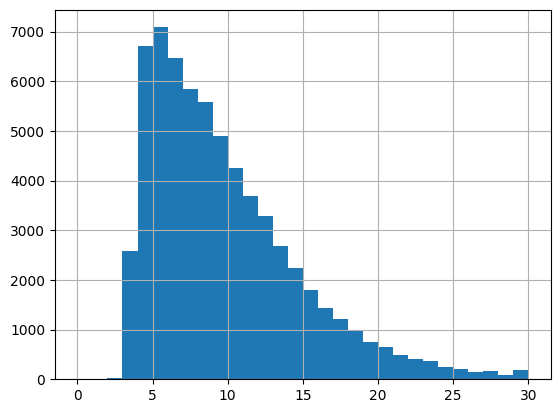

In [14]:
text_word_count = []
for i in dialogs_clean_v2:
    text_word_count.append(len(i.split()))

pd.Series(text_word_count).hist(bins = 30,range=(0,30))

In [15]:
def create_seq(text, seq_len = 5):
    sequences = []
    if len(text.split()) > seq_len:
        for i in range(seq_len, len(text.split())):
            seq = text.split()[i-seq_len:i+1]
            sequences.append(" ".join(seq))
            return sequences
    else:
        return [text]

# create sequences of equal length
seqs = [create_seq(i) for i in dialogs_clean_v2]
seqs = sum(seqs, [])

In [16]:
len(seqs)

64776

In [17]:
seqs[:10]

['hi i <unk> looking to book',
 'somewhe <unk> in southern nyc maybe',
 "we don't w <unk> to sit",
 'what t <unk> a <unk> available',
 "yik <unk> we can't do t",
 'l <unk> me check',
 'great let <unk> book that',
 'no that <unk> it just book',
 'hi i would like to see',
 'y <unk> for me and a']

In [18]:
seqs[:15]

['hi i <unk> looking to book',
 'somewhe <unk> in southern nyc maybe',
 "we don't w <unk> to sit",
 'what t <unk> a <unk> available',
 "yik <unk> we can't do t",
 'l <unk> me check',
 'great let <unk> book that',
 'no that <unk> it just book',
 'hi i would like to see',
 'y <unk> for me and a',
 'what time is that moving playing',
 'what is that about',
 'o <unk> no can y <unk>',
 'w <unk> i like movi <unk>',
 'w <unk> no i like action']

In [19]:
# create input and target sequences (x and y)
x = []
y = []

for s in seqs:
    x.append(" ".join(s.split()[:-1]))
    y.append(" ".join(s.split()[1:]))

In [20]:
len(x)

64776

In [21]:
x[:5], y[:5]

(['hi i <unk> looking to',
  'somewhe <unk> in southern nyc',
  "we don't w <unk> to",
  'what t <unk> a <unk>',
  "yik <unk> we can't do"],
 ['i <unk> looking to book',
  '<unk> in southern nyc maybe',
  "don't w <unk> to sit",
  't <unk> a <unk> available',
  "<unk> we can't do t"])

## 4.2 Create Token-Integer Mappings

In [22]:
# create integer-to-token mapping
int2token = {}
cnt = 1

for w in set(" ".join(dialogs_clean_v2).split()):
    int2token[cnt] = w
    cnt+= 1

# create token-to-integer mapping
token2int = {t: i for i, t in int2token.items()}

In [23]:
token2int["can"], int2token[1127]

(3206, 'cirby')

## 4.3 Split Data into Train and Validation Sets

In [24]:
# train-validation split
# input sequences
x_tr = x[:62000]
x_val = x[62000:]

# target sequences
y_tr = y[:62000]
y_val = y[62000:]

In [25]:
len(x_tr)

62000

In [26]:
x_tr[:10]

['hi i <unk> looking to',
 'somewhe <unk> in southern nyc',
 "we don't w <unk> to",
 'what t <unk> a <unk>',
 "yik <unk> we can't do",
 'l <unk> me',
 'great let <unk> book',
 'no that <unk> it just',
 'hi i would like to',
 'y <unk> for me and']

## 4.4 Pad Sequences

<Axes: >

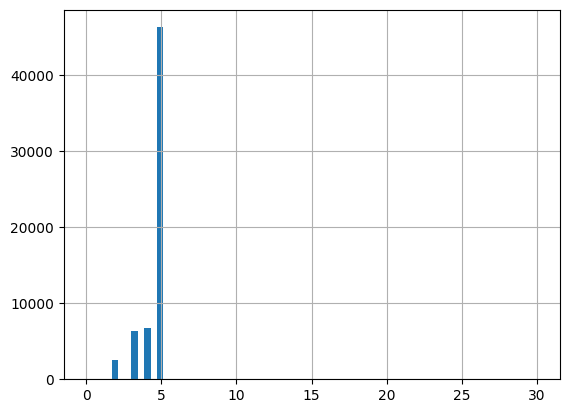

In [27]:
# plot sequence length in train set
text_word_count = []

for i in x_tr:
    text_word_count.append(len(i.split()))

pd.Series(text_word_count).hist(bins = 70,range=(0,30))

In [28]:
# based on the plot above
max_text_len = 5

def pad_sequences(seq, n):

  seq = seq.split()
  if len(seq) < n:
    for i in range(n - len(seq)):
      seq.append("<pad>")

  return " ".join(seq)

# pad text sequences (train set)
x_tr_padded = [pad_sequences(s, max_text_len) for s in x_tr]
y_tr_padded = [pad_sequences(s, max_text_len) for s in y_tr]

# pad text sequences (validation set)
x_val_padded = [pad_sequences(s, max_text_len) for s in x_val]
y_val_padded = [pad_sequences(s, max_text_len) for s in y_val]

In [29]:
len(x_tr_padded)

62000

In [30]:
x_tr_padded[:20]

['hi i <unk> looking to',
 'somewhe <unk> in southern nyc',
 "we don't w <unk> to",
 'what t <unk> a <unk>',
 "yik <unk> we can't do",
 'l <unk> me <pad> <pad>',
 'great let <unk> book <pad>',
 'no that <unk> it just',
 'hi i would like to',
 'y <unk> for me and',
 'what time is that moving',
 'what is that <pad> <pad>',
 'o <unk> no can y',
 'w <unk> i like movi',
 'w <unk> no i like',
 'ok <unk> can i g',
 'ho <unk> muc <unk> wi',
 'y <unk> can i bring',
 'ok <unk> that is <pad>',
 'i w <unk> to watc']

In [31]:
y_tr_padded[:20]

['i <unk> looking to book',
 '<unk> in southern nyc maybe',
 "don't w <unk> to sit",
 't <unk> a <unk> available',
 "<unk> we can't do t",
 '<unk> me check <pad> <pad>',
 'let <unk> book that <pad>',
 'that <unk> it just book',
 'i would like to see',
 '<unk> for me and a',
 'time is that moving playing',
 'is that about <pad> <pad>',
 '<unk> no can y <unk>',
 '<unk> i like movi <unk>',
 '<unk> no i like action',
 '<unk> can i g <unk>',
 '<unk> muc <unk> wi <unk>',
 '<unk> can i bring my',
 '<unk> that is fine <pad>',
 'w <unk> to watc <unk>']

In [32]:
# update mapping dictionaries
int2token[0] = "<pad>"
token2int["<pad>"] = 0

# set vocabulary size
vocab_size = len(int2token)

## 4.5 Convert Text Sequences to Integer Sequences

In [33]:
# function to create integer sequences
def get_integer_seq(seq):
    return [token2int[w] for w in seq.split()]

# convert text sequences to integer sequences
x_tr_int = [get_integer_seq(i) for i in x_tr_padded]
y_tr_int = [get_integer_seq(i) for i in y_tr_padded]

x_val_int = [get_integer_seq(i) for i in x_val_padded]
y_val_int = [get_integer_seq(i) for i in y_val_padded]

In [34]:
x_tr_int[:10]

[[4835, 2404, 4874, 5118, 3525],
 [5057, 4874, 5255, 2290, 4669],
 [517, 4862, 46, 4874, 3525],
 [1390, 1566, 4874, 1905, 4874],
 [2450, 4874, 517, 1838, 2256],
 [4365, 4874, 2740, 0, 0],
 [1103, 796, 4874, 5832, 0],
 [1158, 5633, 4874, 959, 1057],
 [4835, 2404, 4838, 2218, 3525],
 [5413, 4874, 6211, 2740, 2935]]

In [35]:
y_tr_int[:10]

[[2404, 4874, 5118, 3525, 5832],
 [4874, 5255, 2290, 4669, 6203],
 [4862, 46, 4874, 3525, 3325],
 [1566, 4874, 1905, 4874, 441],
 [4874, 517, 1838, 2256, 1566],
 [4874, 2740, 3715, 0, 0],
 [796, 4874, 5832, 5633, 0],
 [5633, 4874, 959, 1057, 5832],
 [2404, 4838, 2218, 3525, 2352],
 [4874, 6211, 2740, 2935, 1905]]

In [36]:
# convert lists into numpy arrays
x_tr_int = np.array(x_tr_int)
y_tr_int = np.array(y_tr_int)

x_val_int = np.array(x_val_int)
y_val_int = np.array(y_val_int)

x_tr_int.shape, y_tr_int.shape, x_val_int.shape, y_val_int.shape

((62000, 5), (62000, 5), (2776, 5), (2776, 5))

# 5. Model Building

## 5.1 Define Model Architecture

In [37]:
##### Upgraded Version Bi-drectional LSTM #####
class WordLSTM(nn.Module):
    def __init__(self, embedding_dim=200, n_hidden=256, n_layers=2, drop_prob=0.3, lr=0.001, bidirectional=False):
        super(WordLSTM, self).__init__()
        self.n_hidden = n_hidden
        self.n_layers = n_layers
        self.embedding_dim = embedding_dim
        self.bidirectional = bidirectional

        self.embed = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, n_hidden, n_layers, batch_first=True, dropout=drop_prob, bidirectional=bidirectional)
        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(n_hidden * 2 if bidirectional else n_hidden, vocab_size)
        self.init_weights()

    def forward(self, x, hidden):
        embedded = self.embed(x)
        lstm_out, hidden = self.lstm(embedded, hidden)
        out = self.dropout(lstm_out)
        out = out.reshape(-1, self.n_hidden * 2 if self.bidirectional else self.n_hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        weight = next(self.parameters()).data
        number = 2 if self.bidirectional else 1
        return (weight.new(self.n_layers * number, batch_size, self.n_hidden).zero_().to(weight.device),
                weight.new(self.n_layers * number, batch_size, self.n_hidden).zero_().to(weight.device))

    def init_weights(self):
        for name, param in self.named_parameters():
            if 'weight_ih' in name:
                torch.nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                torch.nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)

In [38]:
# define and print the net
net = WordLSTM()
print(net)

WordLSTM(
  (embed): Embedding(6245, 200)
  (lstm): LSTM(200, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=6245, bias=True)
)


In [39]:
# function to generate batches
def get_batches(arr_x, arr_y, batch_size):

    prv = 0
    for n in range(batch_size, arr_x.shape[0], batch_size):
        # batch of input sequences
        x = arr_x[prv:n,:]
        # batch of target sequences
        y = arr_y[prv:n,:]
        prv = n
        yield x, y

## 5.2 Start Model Training

In [40]:
def train(net, epochs=10, batch_size=32, lr=0.001, print_every=32):
    # Determine device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    net.to(device)

    # Initialize optimizer and loss function
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_valid_loss = float('inf')
    counter = 0
    net.train()

    for e in range(epochs):

        for x, y in get_batches(x_tr_int, y_tr_int, batch_size):
            counter += 1
            x, y = torch.from_numpy(x).to(device), torch.from_numpy(y).to(device)
            h = net.init_hidden(batch_size)
            net.zero_grad()
            output, h = net(x, h)
            loss = criterion(output, y.view(-1))
            loss.backward()
            opt.step()

            if (e * len(x_tr_int) / batch_size + counter) % print_every == 0:
                val_losses = []
                net.eval()
                with torch.no_grad():
                    for x, y in get_batches(x_val_int, y_val_int, batch_size):
                        x, y = torch.from_numpy(x).to(device), torch.from_numpy(y).to(device)
                        val_h = net.init_hidden(batch_size)
                        output, val_h = net(x, val_h)
                        val_loss = criterion(output, y.view(-1))
                        val_losses.append(val_loss.item())

                net.train()
                avg_val_loss = np.mean(val_losses)
                if avg_val_loss < best_valid_loss:
                    best_valid_loss = avg_val_loss
                    torch.save(net.state_dict(), 'saved_weights.pt')

                print(f"Epoch: {e+1}/{epochs}...",
                      f"Step: {(e * len(x_tr_int) / batch_size + counter)}...",
                      f"Loss: {loss.item():.4f}...",
                      f"Val Loss: {avg_val_loss:.4f}",
                      f"Val PPL: {np.exp(avg_val_loss):.4f}")

In [41]:
batch_size = 64
train(net, batch_size = batch_size, epochs=10)

Epoch: 1/10... Step: 32.0... Loss: 4.9053... Val Loss: 4.8724 Val PPL: 130.6399
Epoch: 1/10... Step: 64.0... Loss: 4.5456... Val Loss: 4.3333 Val PPL: 76.1961
Epoch: 1/10... Step: 96.0... Loss: 4.0991... Val Loss: 4.0475 Val PPL: 57.2552
Epoch: 1/10... Step: 128.0... Loss: 3.8390... Val Loss: 3.8683 Val PPL: 47.8592
Epoch: 1/10... Step: 160.0... Loss: 3.6007... Val Loss: 3.7356 Val PPL: 41.9117
Epoch: 1/10... Step: 192.0... Loss: 3.8517... Val Loss: 3.6294 Val PPL: 37.6888
Epoch: 1/10... Step: 224.0... Loss: 3.5176... Val Loss: 3.5512 Val PPL: 34.8550
Epoch: 1/10... Step: 256.0... Loss: 3.2649... Val Loss: 3.4624 Val PPL: 31.8933
Epoch: 1/10... Step: 288.0... Loss: 3.4602... Val Loss: 3.3963 Val PPL: 29.8528
Epoch: 1/10... Step: 320.0... Loss: 3.1969... Val Loss: 3.3284 Val PPL: 27.8925
Epoch: 1/10... Step: 352.0... Loss: 3.1446... Val Loss: 3.2624 Val PPL: 26.1128
Epoch: 1/10... Step: 384.0... Loss: 3.2888... Val Loss: 3.2065 Val PPL: 24.6926
Epoch: 1/10... Step: 416.0... Loss: 3.2154

# 6. Text Generation

In [42]:
#load weights of best model
path = 'saved_weights.pt'
net.load_state_dict(torch.load(path))

<ipython-input-42-940e25f5c056>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(path))


<All keys matched successfully>

In [43]:
# function to generate one token
def predict(net, tkn, h=None):

    x = np.array([[token2int[tkn]]])
    inputs = torch.from_numpy(x)

    if(torch.cuda.is_available()):
        inputs = inputs.cuda()
    out, h = net(inputs, h)
    p = F.softmax(out, dim=1).data

    if(torch.cuda.is_available()):
        p = p.cpu()
    p = p.numpy()
    sampled_token_index = np.argmax(p, axis = 1)[0]

    return int2token[sampled_token_index], h

# function to fetch generated sequence
def sample(net, size = 2, seed_text='it is'):

    if(torch.cuda.is_available()):
        net.cuda()
    net.eval()
    h = net.init_hidden(1)
    toks = seed_text.split()

    # predict next token
    for t in toks:
        token, h = predict(net, t, h)
    toks.append(token)
    for i in range(size-1):
        token, h = predict(net, toks[-1], h)
        toks.append(token)

    return ' '.join(toks)

In [59]:
x_val_padded[50:80]

['what a bumm <unk> that',
 "they don't ha <unk> anything",
 'we can g <unk> dinn',
 'they just keep <unk> mo',
 't <unk> y <unk> appreci',
 'hi mary can y <unk>',
 'i would lo <unk> an',
 'o <unk> right <pad> <pad>',
 'o <unk> no t <unk>',
 'skim milk <pad> <pad> <pad>',
 'no t <unk> <pad> <pad>',
 't <unk> y <unk> so',
 'awesome t <unk> y <unk>',
 'i wi <unk> <pad> <pad>',
 'ho <unk> a <unk> <unk>',
 'let <unk> do <pad> <pad>',
 'do <unk> the restaur <unk>',
 'do <unk> the restaur <unk>',
 'ho <unk> muc <unk> is',
 'great can we g <unk>',
 'sounds great <pad> <pad> <pad>',
 'i w <unk> to find',
 'try hudson or ri <unk>',
 'do <unk> ei <unk> restaur',
 'that sounds <pad> <pad> <pad>',
 'do <unk> the restaur <unk>',
 'could i book a table',
 'can y <unk> send me',
 "i'd like to book a",
 'in <unk> <pad> <pad> <pad>']

In [62]:
# seed texts
seeds = ["i need the truck",
         "that won't",
         "they don't",
         "what coffee"]

# number of tokens to generate
num_toks = 6

# text generation
for s in seeds:
    # get generated text from the model
    text_gen = sample(net, num_toks, seed_text=s)
    # print the result
    print("seed text:", s, ">> output:",text_gen)
    print("\n")

seed text: i need the truck >> output: i need the truck for me and my friend and


seed text: that won't >> output: that won't work for me and my friend


seed text: they don't >> output: they don't ha <unk> a <unk> of them


seed text: what coffee >> output: what coffee is available for the movie tickets


